# **模块**: 单变量统计过程监控
## **课程**: CUSUM控制图的工业应用
### *主题*:  基于CUSUM控制图的曝气池监控

In [2]:
# 导入所需包
import numpy as np
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [3]:
# ==================================================================================
#                        读取并探索数据集
# ==================================================================================

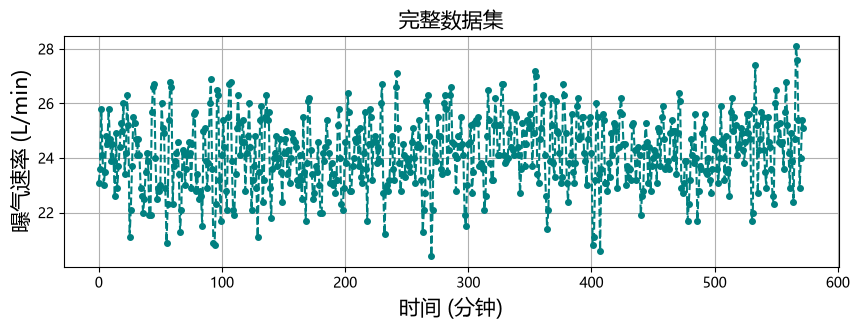

In [5]:
# 读取数据
data = np.loadtxt('aeration-rate.csv', skiprows=1)

# 绘图
plt.figure(figsize=(10,3))
plt.plot(data,'--',marker='o', markersize=4, color='teal')
plt.xlabel('时间 (分钟)', fontsize=15), plt.ylabel('曝气速率 (L/min)', fontsize=15)
plt.title('完整数据集', fontsize=15)
plt.grid()
plt.show()

In [4]:
# ==================================================================================
#                                    模型训练
# ==================================================================================

> ##### 将使用前200个样本作为NOC数据估计CUSUM控制图参数：信号的均值(mu)、标准差(sigma)以及控制限(H)

In [6]:
# 获取NOC数据
N = 200
x_faultFree = data[:N]

In [7]:
# 估计CUSUM模型参数并为NOC数据绘制控制图
mu, sigma = np.mean(x_faultFree), np.std(x_faultFree)
k = 0.25*sigma
H = 5*sigma

print(f'CUSUM 控制图控制限：{H}')

CUSUM 控制图控制限：6.81867839100804


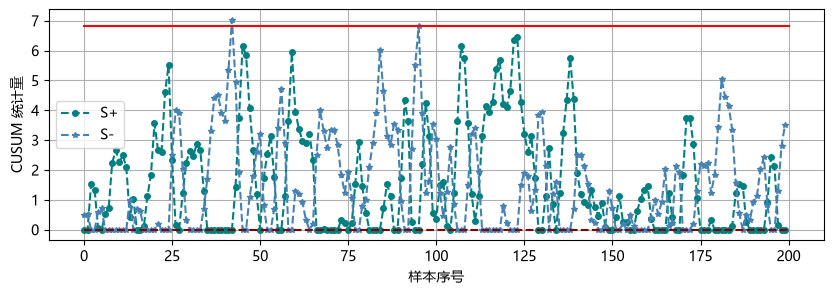

In [8]:
# 计算NOC数据的CUSUM统计量
S_positive = np.zeros((len(x_faultFree),))
S_negative = np.zeros((len(x_faultFree),))

for i in range(len(x_faultFree)):
    if i==0:
        S_positive[i] = np.max([0, x_faultFree[i]-(mu+k)])
        S_negative[i] = np.max([0, (mu-k)-x_faultFree[i]])
    else:
        S_positive[i] = np.max([0, x_faultFree[i]-(mu+k) + S_positive[i-1]])
        S_negative[i] = np.max([0, (mu-k)-x_faultFree[i] + S_negative[i-1]])

# 绘制NOC数据控制图
plt.figure(figsize=(10,3))
plt.plot(S_positive,'--',marker='o', markersize=4, color='teal', label='S+')
plt.plot(S_negative,'--',marker='*', markersize=4, color='steelblue', label='S-')
plt.plot([0,N],[H,H], color='red')
plt.plot([0,N],[0,0], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('CUSUM 统计量')
plt.grid(), plt.legend()
plt.show()

In [8]:
# ==================================================================================
#               获取测试样本并绘制在控制图上
# ==================================================================================

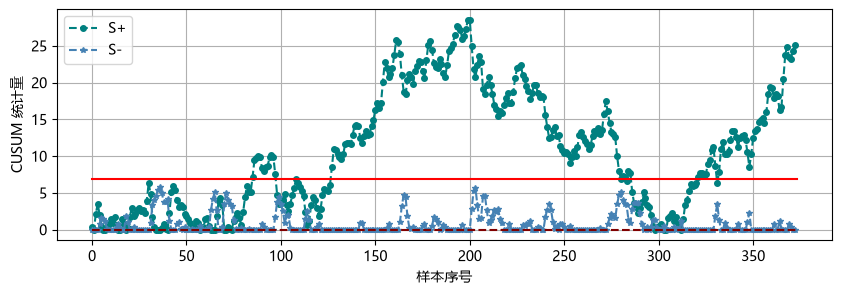

In [9]:
# 测试数据
x_test = data[200:]
N_test = len(x_test)

# 故障数据的CUSUM统计量
S_positive_test = np.zeros((len(x_test),))
S_negative_test = np.zeros((len(x_test),))

for i in range(len(x_test)):
    if i==0:
        S_positive_test[i] = np.max([0, x_test[i]-(mu+k)])
        S_negative_test[i] = np.max([0, (mu-k)-x_test[i]]) 
    else:
        S_positive_test[i] = np.max([0, x_test[i]-(mu+k) + S_positive_test[i-1]])
        S_negative_test[i] = np.max([0, (mu-k)-x_test[i] + S_negative_test[i-1]])

# 绘制测试数据控制图
plt.figure(figsize=(10,3))
plt.plot(S_positive_test,'--',marker='o', markersize=4, color='teal', label='S+')
plt.plot(S_negative_test,'--',marker='*', markersize=4, color='steelblue', label='S-')
plt.plot([0,N_test],[H,H], color='red')
plt.plot([0,N_test],[0,0], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('CUSUM 统计量')
plt.grid(), plt.legend()
plt.show()

In [10]:
# ==================================================================================
#                   所有样本合并的控制图
# ==================================================================================

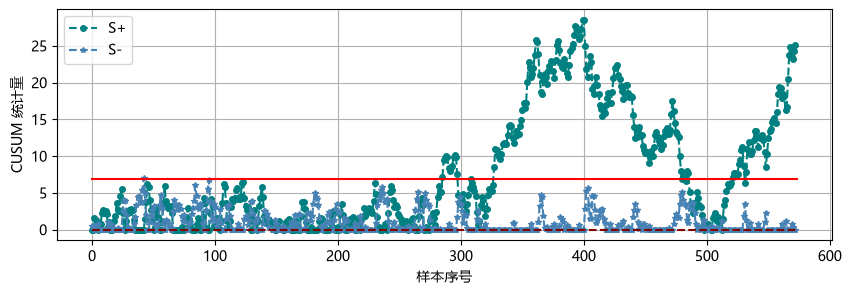

In [10]:
# 合并数据的CUSUM统计量与控制图
x_combined = data

S_positive = np.zeros((len(x_combined),))
S_negative = np.zeros((len(x_combined),))

for i in range(len(x_combined)):
    if i==0:
        S_positive[i] = np.max([0, x_combined[i]-(mu+k)])
        S_negative[i] = np.max([0, (mu-k)-x_combined[i]]) 
    else:
        S_positive[i] = np.max([0, x_combined[i]-(mu+k) + S_positive[i-1]])
        S_negative[i] = np.max([0, (mu-k)-x_combined[i] + S_negative[i-1]])

plt.figure(figsize=(10,3))
plt.plot(S_positive,'--',marker='o', markersize=4, color='teal', label='S+')
plt.plot(S_negative,'--',marker='*', markersize=4, color='steelblue', label='S-')
plt.plot([0,len(x_combined)],[H,H], color='red')
plt.plot([0,len(x_combined)],[0,0], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('CUSUM 统计量')
plt.grid()
plt.legend()
plt.show()